# Lab 08

### Nguyễn Phúc Minh Châu - 22302421

In [4]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support

from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [5]:
# read data
data = pd.read_csv('diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 1. Plot a pie chart for class distribution

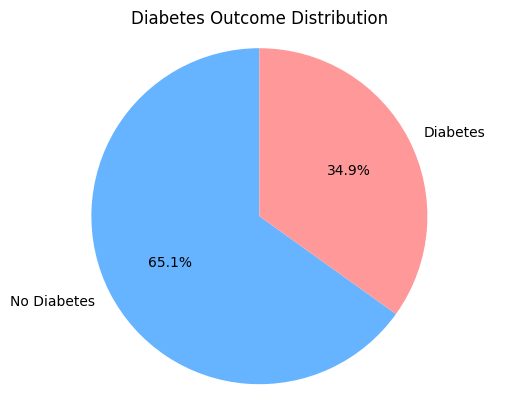

In [6]:
# pie chart for outcome
outcome_counts = data['Outcome'].value_counts()
labels = ['No Diabetes', 'Diabetes']
plt.pie(outcome_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Diabetes Outcome Distribution')
plt.axis('equal')
plt.show()

## 2.Use Logistic Regression, evaluate the accuracy of the model on predicting of a diabetic person.

Accuracy: 0.75
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154

Confusion Matrix:


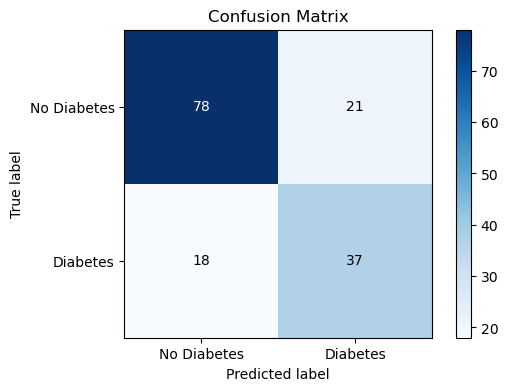

In [24]:
# Logistic Regression
X = data.drop('Outcome', axis=1)
y = data['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

print('Classification Report:')
print(classification_report(y_test, y_pred))

print('Confusion Matrix:')
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.colorbar()
# Annotate each cell with the numeric value
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha='center', va='center', color='white' if cm[i, j] > thresh else 'black')
plt.xticks(np.arange(2), labels)
plt.yticks(np.arange(2), labels)
plt.show()

## 3. Normalize the data with Min-Max Scaling, and use Logistic Regression, evaluate the accuracy of the model on predicting of a diabetic person.

Accuracy (Min-Max scaled): 0.77
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.87      0.83        99
           1       0.71      0.58      0.64        55

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.73       154
weighted avg       0.76      0.77      0.76       154



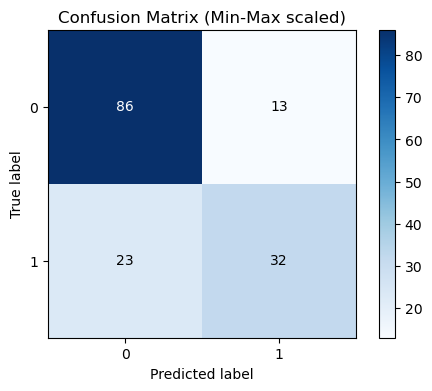

In [23]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy (Min-Max scaled): {accuracy:.2f}')

print('Classification Report:')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Min-Max scaled)')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.colorbar()
# Annotate counts in each cell
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha='center', va='center', color='white' if cm[i, j] > thresh else 'black')
plt.xticks([0,1])
plt.yticks([0,1])
plt.show()

## 4. Normalize the data with Z-score Scaling, and use Logistic Regression, evaluate the accuracy of the model on predicting of a diabetic person. 

Accuracy (Z-score scaled): 0.75
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



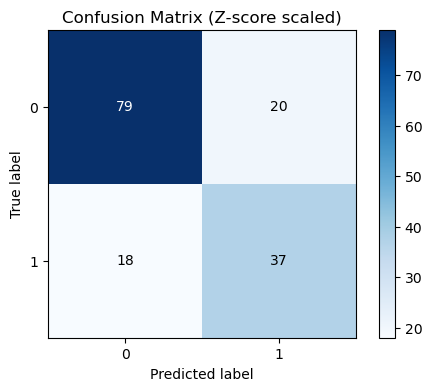

In [22]:
# Z-score (Standard) Scaling + Logistic Regression
X = data.drop('Outcome', axis=1)
y = data['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy (Z-score scaled): {accuracy:.2f}')

print('Classification Report:')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Z-score scaled)')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.colorbar()
# Annotate counts in each cell
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha='center', va='center', color='white' if cm[i, j] > thresh else 'black')
plt.xticks([0,1])
plt.yticks([0,1])
plt.show()

## 5.Compare the results of 2, 3 and 4. 

Summary metrics (rounded to 2 decimals):
Preprocessing  Accuracy  Precision  Recall  F1-score
          Raw      0.75       0.64    0.67      0.65
      Min-Max      0.77       0.71    0.58      0.64
      Z-score      0.75       0.65    0.67      0.66

Confusion Matrix for Raw:
             No Diabetes  Diabetes
No Diabetes           78        21
Diabetes              18        37

Confusion Matrix for Min-Max:
             No Diabetes  Diabetes
No Diabetes           86        13
Diabetes              23        32

Confusion Matrix for Z-score:
             No Diabetes  Diabetes
No Diabetes           79        20
Diabetes              18        37


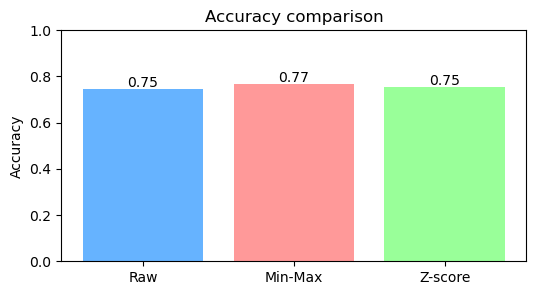

In [ ]:
# Run and compare models for raw, Min-Max and Z-score preprocessing
X = data.drop('Outcome', axis=1)
y = data['Outcome']

def evaluate_model(X, y, scaler=None):
    if scaler is not None:
        X_proc = scaler.fit_transform(X)
    else:
        X_proc = X.values if hasattr(X, 'values') else X

    X_train, X_test, y_train, y_test = train_test_split(X_proc, y, test_size=0.2, random_state=42)
    model = LogisticRegression(max_iter=200)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    return { 'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'cm': cm }

results = {}
results['Raw'] = evaluate_model(X, y, scaler=None)
results['Min-Max'] = evaluate_model(X, y, scaler=MinMaxScaler())
results['Z-score'] = evaluate_model(X, y, scaler=StandardScaler())

# Summary table
summary = []
for prep, res in results.items():
    summary.append({
        'Preprocessing': prep,
        'Accuracy': res['accuracy'],
        'Precision': res['precision'],
        'Recall': res['recall'],
        'F1-score': res['f1']
    })

summary_df = pd.DataFrame(summary)
print('Summary metrics (rounded to 2 decimals):')
print(summary_df.round(2).to_string(index=False))

# Print confusion matrices
labels = ['No Diabetes', 'Diabetes']
for prep, res in results.items():
    print(f"\nConfusion Matrix for {prep}:")
    cm = res['cm']
    print(pd.DataFrame(cm, index=labels, columns=labels))

# Optional plot of accuracies
try:
    plt.figure(figsize=(6,3))
    plt.bar(summary_df['Preprocessing'], summary_df['Accuracy'], color=['#66b3ff','#ff9999','#99ff99'])
    plt.ylim(0,1)
    plt.title('Accuracy comparison')
    plt.ylabel('Accuracy')
    for i, v in enumerate(summary_df['Accuracy']):
        plt.text(i, v+0.01, f"{v:.2f}", ha='center')
    plt.show()
except Exception as e:
    print('Plot skipped:', e)